In [13]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2

from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli, Statevector
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_gate_map
from qiskit.transpiler import CouplingMap

sys.path.append("../../pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


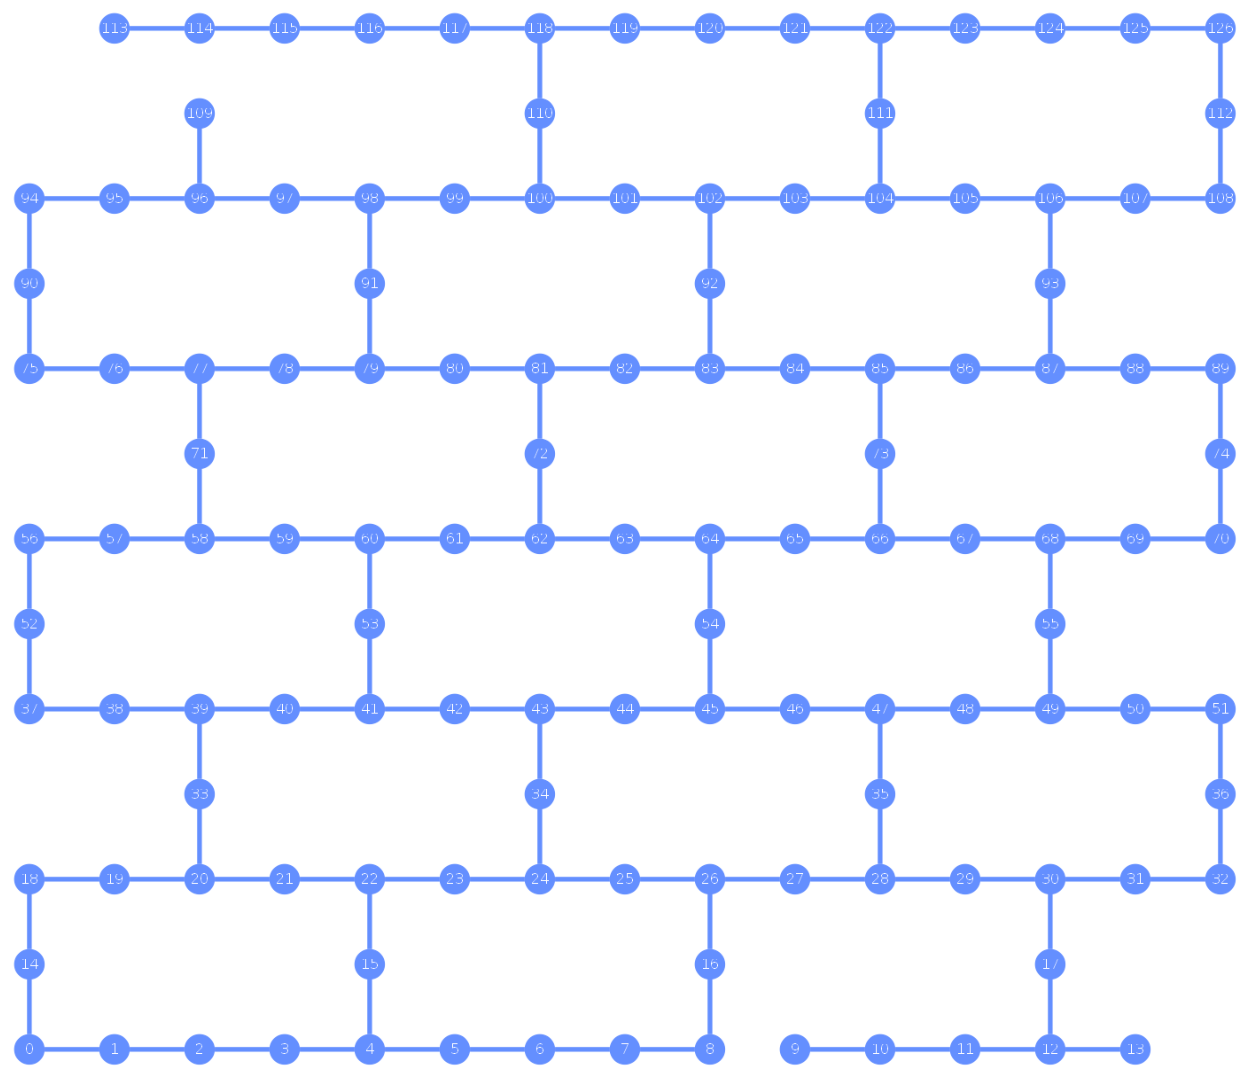

In [14]:
backend = FakeWashingtonV2()
plot_gate_map(backend)
"""coupling_list = backend.configuration().coupling_map
print("Coupling Map:", coupling_list)"""

noise_model = NoiseModel.from_backend(backend)
simulator = AerSimulator.from_backend(backend)


In [3]:
properties = backend.properties()

for qubit in range(backend.num_qubits):
    t1 = properties.t1(qubit)
    t2 = properties.t2(qubit)
    readout_err = properties.readout_error(qubit)
    print(f"Qubit {qubit}: T1 = {t1:.2e} s, T2 = {t2:.2e} s, Readout Error = {readout_err:.4f}")

Qubit 0: T1 = 6.93e-05 s, T2 = 1.41e-05 s, Readout Error = 0.0065
Qubit 1: T1 = 1.12e-04 s, T2 = 9.73e-05 s, Readout Error = 0.0121
Qubit 2: T1 = 8.11e-05 s, T2 = 1.76e-05 s, Readout Error = 0.0189
Qubit 3: T1 = 1.05e-04 s, T2 = 3.17e-05 s, Readout Error = 0.0419
Qubit 4: T1 = 1.11e-04 s, T2 = 9.68e-05 s, Readout Error = 0.1011
Qubit 5: T1 = 1.00e-04 s, T2 = 1.31e-04 s, Readout Error = 0.0525
Qubit 6: T1 = 1.03e-04 s, T2 = 1.40e-04 s, Readout Error = 0.0104
Qubit 7: T1 = 9.83e-05 s, T2 = 5.92e-05 s, Readout Error = 0.0115
Qubit 8: T1 = 6.44e-05 s, T2 = 8.98e-05 s, Readout Error = 0.0137
Qubit 9: T1 = 1.11e-04 s, T2 = 1.53e-04 s, Readout Error = 0.1200
Qubit 10: T1 = 8.20e-05 s, T2 = 7.83e-05 s, Readout Error = 0.0631
Qubit 11: T1 = 1.44e-04 s, T2 = 5.00e-05 s, Readout Error = 0.1319
Qubit 12: T1 = 1.42e-04 s, T2 = 1.10e-04 s, Readout Error = 0.2450
Qubit 13: T1 = 6.51e-05 s, T2 = 1.96e-05 s, Readout Error = 0.0105
Qubit 14: T1 = 8.17e-05 s, T2 = 8.61e-05 s, Readout Error = 0.0126
Qubit

In [4]:

# 1. Circuit: GHZ-State mit 4 Qubits → Erwartungswert von XXXX = +1
n = 4
qc = QuantumCircuit(n)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)

# Idealer Erwartungswert berechnen
pauli = Pauli("XXXX")
target_value = Statevector.from_instruction(qc).expectation_value(pauli)
print(f"Idealer Erwartungswert XXXX = {target_value.real:.3f}")

inst_map = [0,1,2,3]

experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits= [0,1,2,3]
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

#run the experiment
experiment.run(executor)

noisedataframe = experiment.analyze()

Idealer Erwartungswert XXXX = 1.000


c:\Users\kchar\OneDrive\Desktop\Uni\Hiwi_Orth\Qiskit\qiskit-venv\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(
c:\Users\kchar\OneDrive\Desktop\Uni\Hiwi_Orth\Qiskit\qiskit-venv\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


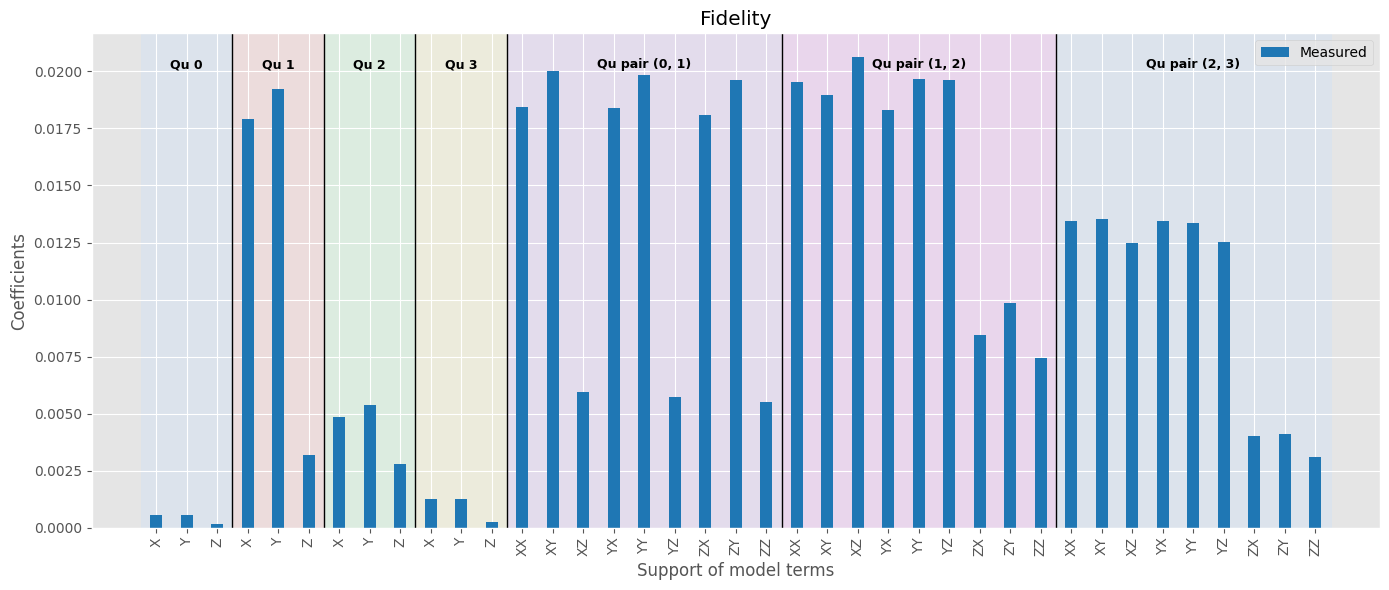

In [5]:
layer = experiment.analysis.get_layer_data(0)
layer.plot_infidelitites(plot_style = 2)

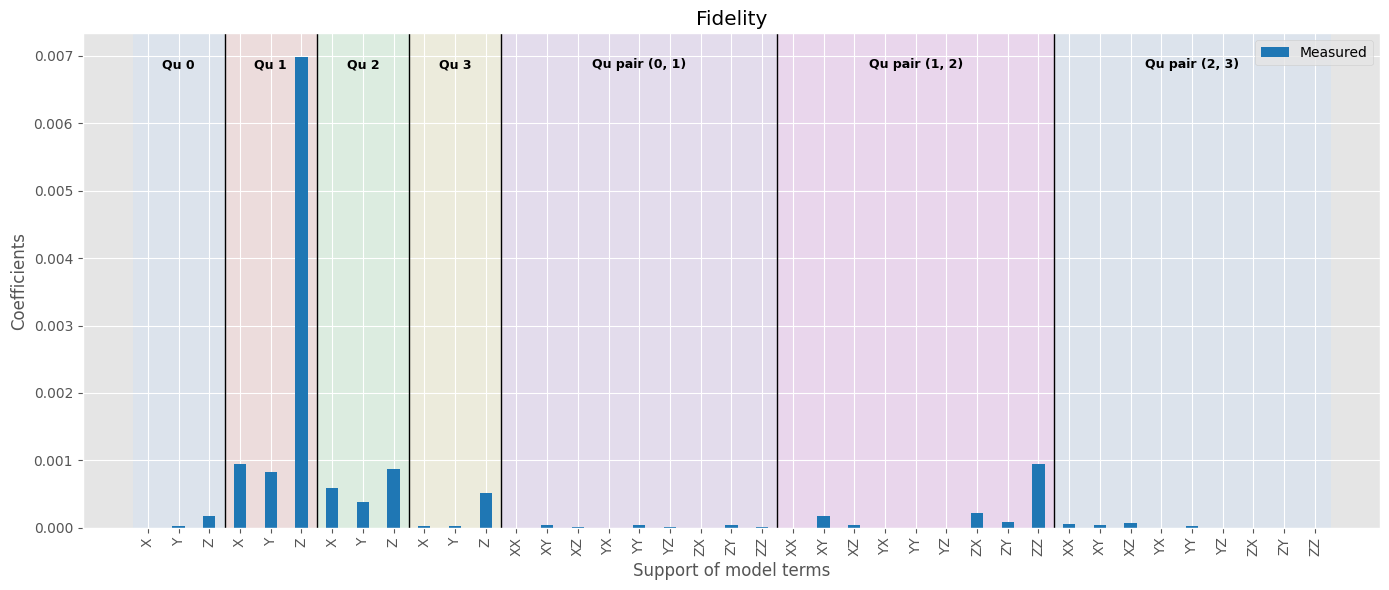

In [6]:
layer.plot_coeffs(plot_style = 2)

In [ ]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc])

perexp.generate(
    expectations=["XXXX"],
    samples=500,
    noise_strengths=[0, 1, 2]
)

# 3. Ausführen
perexp.run(executor)

# 4. Analysieren
per_results = perexp.analyze()
result_xxxx = per_results[0].get_result("XXXX")


c:\Users\kchar\OneDrive\Desktop\Uni\Hiwi_Orth\Qiskit\qiskit-venv\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


<Axes: >

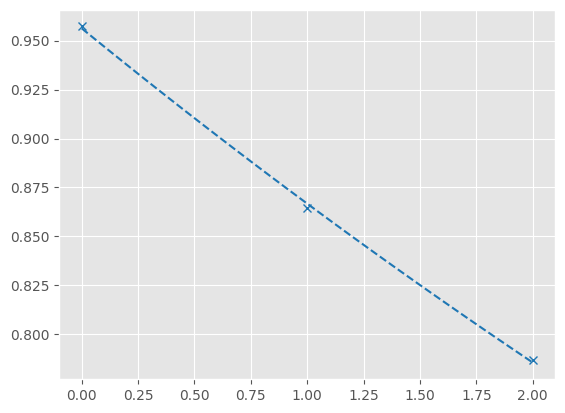

In [11]:
result_xxxx.plot()

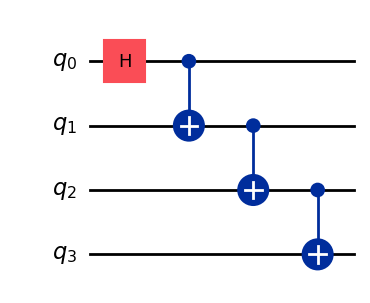

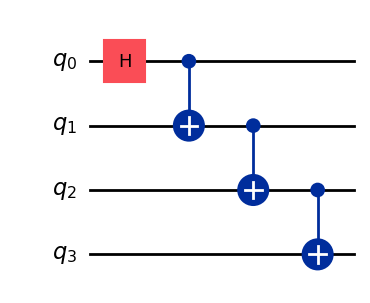

In [12]:
qc.draw('mpl')